# Étape 2 : Exploration des données (EDA)
## Projet : Analyser les transactions pour détecter la fraude bancaire

**EDA = Exploratory Data Analysis.** C'est l'étape où l'on *observe* les données avant de les modifier ou de modéliser quoi que ce soit. L'objectif est de comprendre, pas de corriger.

**Questions auxquelles ce notebook répond :**
1. À quoi ressemblent les données (taille, types, aperçu) ?
2. Y a-t-il des valeurs manquantes ou des doublons ?
3. Quel est le déséquilibre entre fraudes et transactions normales ?
4. Les montants des fraudes diffèrent-ils de ceux des transactions normales ?
5. Y a-t-il un moment de la journée où la fraude est plus fréquente ?
6. Quelles variables `V1`-`V28` distinguent le mieux les fraudes ?
7. Les variables sont-elles corrélées entre elles et avec la cible ?
8. Les fraudes sont-elles visuellement séparables des transactions normales ?

## 1. Préparation

### 1.1 Bibliothèques et dossiers


In [1]:
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
for dossier in (PROCESSED_DIR, FIG_DIR):
    dossier.mkdir(parents=True, exist_ok=True)

CSV_PATH = RAW_DIR / "creditcard.csv"
if not CSV_PATH.exists():
    raise FileNotFoundError(
        "creditcard.csv est introuvable dans data/raw/. Termine d'abord l'étape 1 (collecte)."
    )

# Couleurs et noms cohérents dans tous les graphiques
COULEURS = {0: "#4C72B0", 1: "#C44E52"}   # bleu = normale, rouge = fraude
NOMS = {0: "Normale", 1: "Fraude"}

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 40)


def sauver(nom):
    plt.savefig(FIG_DIR / f"{nom}.png", dpi=150, bbox_inches="tight")


print("Racine du projet :", PROJECT_ROOT)

Racine du projet : /home/virlence-manga-bell/Documents/DataScience/fraude-bancaire-detection


### 1.2 Chargement

In [2]:
df = pd.read_csv(CSV_PATH)
V_COLS = [f"V{i}" for i in range(1, 29)]

print(f"{df.shape[0]:,} lignes x {df.shape[1]} colonnes".replace(",", " "))

284 807 lignes x 31 colonnes


## 2. Vue d'ensemble

### 2.1 Structure et aperçu

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
display(df.head())
display(df.tail())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0000,-11.8811,10.0718,-9.8348,-2.0667,-5.3645,-2.6068,-4.9182,7.3053,1.9144,4.3562,-1.5931,2.7119,-0.6893,4.6269,-0.9245,1.1076,1.9917,0.5106,-0.6829,1.4758,0.2135,0.1119,1.0145,-0.5093,1.4368,0.2500,0.9437,0.8237,0.7700,0
284803,172787.0000,-0.7328,-0.0551,2.0350,-0.7386,0.8682,1.0584,0.0243,0.2949,0.5848,-0.9759,-0.1502,0.9158,1.2148,-0.6751,1.1649,-0.7118,-0.0257,-1.2212,-1.5456,0.0596,0.2142,0.9244,0.0125,-1.0162,-0.6066,-0.3953,0.0685,-0.0535,24.7900,0
284804,172788.0000,1.9196,-0.3013,-3.2496,-0.5578,2.6305,3.0313,-0.2968,0.7084,0.4325,-0.4848,0.4116,0.0631,-0.1837,-0.5106,1.3293,0.1407,0.3135,0.3957,-0.5773,0.0014,0.2320,0.5782,-0.0375,0.6401,0.2657,-0.0874,0.0045,-0.0266,67.8800,0
284805,172788.0000,-0.2404,0.5305,0.7025,0.6898,-0.3780,0.6237,-0.6862,0.6791,0.3921,-0.3991,-1.9338,-0.9629,-1.0421,0.4496,1.9626,-0.6086,0.5099,1.1140,2.8978,0.1274,0.2652,0.8000,-0.1633,0.1232,-0.5692,0.5467,0.1088,0.1045,10.0000,0
284806,172792.0000,-0.5334,-0.1897,0.7033,-0.5063,-0.0125,-0.6496,1.5770,-0.4147,0.4862,-0.9154,-1.0405,-0.0315,-0.1881,-0.0843,0.0413,-0.3026,-0.6604,0.1674,-0.2561,0.3829,0.2611,0.6431,0.3768,0.0088,-0.4736,-0.8183,-0.0024,0.0136,217.0000,0


### 2.2 Statistiques descriptives

`describe()` résume chaque colonne : moyenne (`mean`), écart-type (`std`), minimum, quartiles (25 %, 50 % = médiane, 75 %) et maximum.

#### Moyenne, écart type et percentiles

Ces trois outils répondent à des questions différentes sur une série de valeurs :

| Outil | Question posée | Sensible aux extrêmes ? |
|---|---|---|
| Moyenne | Où est le centre ? | Oui |
| Écart type | Quelle est la dispersion autour du centre ? | Oui |
| Percentiles, médiane, IQR | Comment les valeurs se répartissent-elles ? | Non |

---

##### 1. La moyenne : le centre de gravité

**Définition :** on additionne toutes les valeurs et on divise par leur nombre.

$$\mu = \frac{x_1 + x_2 + \dots + x_n}{n} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**Interprétation :** c'est la valeur « typique » si les données sont réparties de façon équilibrée. Elle est très sensible aux valeurs extrêmes.


---

##### 2. L'écart type : la dispersion

**Définition :** racine carrée de la moyenne des carrés des écarts à la moyenne.

$$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}$$

Sur un **échantillon**, on divise par $n-1$ au lieu de $n$ (correction de Bessel) :

$$s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

**Interprétation :** c'est l'écart typique autour de la moyenne, dans la même unité que les données.

- Écart type faible : valeurs regroupées autour de la moyenne.
- Écart type élevé : valeurs très dispersées.

Le carré de l'écart type est la **variance** : $\sigma^2$.

---

##### 3. Les percentiles : la position dans la distribution

**Définition :** le percentile $P_k$ est la valeur en dessous de laquelle se trouvent $k\,\%$ des observations.

- **$P_{50}$** : la **médiane** (la moitié des données de chaque côté).
- **$P_{25}$ et $P_{75}$** : les **quartiles**.
- **IQR** (intervalle interquartile) : $IQR = P_{75} - P_{25}$.
- **$P_{95}$, $P_{99}$** : valeurs « rares mais hautes ».

**Interprétation :** les percentiles décrivent la forme réelle de la distribution et sont peu influencés par les valeurs extrêmes.

---

##### 4. Le z-score : mesurer un écart en nombre d'écarts types

$$z = \frac{x - \mu}{\sigma}$$

Un $z = 2$ signifie que la valeur est à 2 écarts types au-dessus de la moyenne.

---

##### 5. Comment ils sont reliés

##### a) Moyenne vs médiane : l'asymétrie

| Situation | Lecture |
|---|---|
| Moyenne ≈ médiane | Distribution à peu près symétrique |
| Moyenne > médiane | Queue longue vers les hautes valeurs (revenus, prix immobiliers) |
| Moyenne < médiane | Queue longue vers les basses valeurs |

##### b) Écart type et percentiles : la loi normale

Pour une loi normale, la règle **68-95-99,7** s'applique :

| Intervalle | Part des valeurs | Percentiles correspondants |
|---|---|---|
| $\mu \pm 1\sigma$ | ≈ 68 % | de $P_{16}$ à $P_{84}$ |
| $\mu \pm 2\sigma$ | ≈ 95 % | de $P_{2,5}$ à $P_{97,5}$ |
| $\mu \pm 3\sigma$ | ≈ 99,7 % | de $P_{0,15}$ à $P_{99,85}$ |

Dans ce cas, $\mu = P_{50}$ et $IQR \approx 1{,}35\,\sigma$.

##### c) Hors loi normale

Sur des données asymétriques ou avec des valeurs aberrantes, l'écart type est gonflé par les extrêmes, alors que les percentiles restent fiables. On associe donc :

- **moyenne + écart type** (approche sensible aux extrêmes) ;
- **médiane + IQR** (approche robuste).

---

##### 6. Interprétations et usages en data science

- **Exploration des données :** comparer moyenne, médiane et percentiles pour repérer l'asymétrie et les valeurs aberrantes.
- **Détection d'anomalies :**
  - méthode du z-score : $|z| > 3$ ;
  - méthode de l'IQR (règle du boxplot) : valeur hors de $[P_{25} - 1{,}5\,IQR \; ; \; P_{75} + 1{,}5\,IQR]$, plus robuste.
- **Normalisation :** la standardisation $\frac{x-\mu}{\sigma}$ met les variables à la même échelle (régression, k-means, SVM, réseaux de neurones).
- **Performance et fiabilité :** on suit le $P_{95}$ ou $P_{99}$ des temps de réponse plutôt que la moyenne. Une moyenne de 200 ms peut cacher 1 % de requêtes à 5 s.
- **Comparaison de groupes :** deux groupes de même moyenne mais d'écarts types différents n'ont pas le même comportement.
- **Évaluation de modèles :** l'écart type des erreurs mesure la stabilité ; le $P_{90}$ des erreurs indique les pires cas courants.
- **Inférence statistique :** l'écart type sert à calculer l'erreur standard $\frac{\sigma}{\sqrt{n}}$, qui mesure la précision de la moyenne estimée.

In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0000,94813.8596,47488.1460,0.0000,54201.5000,84692.0000,139320.5000,172792.0000
V1,284807.0000,0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,284807.0000,0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,284807.0000,-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,284807.0000,0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,284807.0000,0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,284807.0000,0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,284807.0000,-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,284807.0000,0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,284807.0000,-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


## 3. Valeurs manquantes et doublons


In [6]:
manquantes = int(df.isnull().sum().sum())
print("Valeurs manquantes (total) :", manquantes)

masque_doublons = df.duplicated()
n_doublons = int(masque_doublons.sum())
print(f"Lignes dupliquées : {n_doublons} ({n_doublons / len(df):.3%} du jeu de données)")

if n_doublons > 0:
    print()
    print("Répartition des doublons par classe :")
    print(df.loc[masque_doublons, "Class"].map(NOMS).value_counts())

Valeurs manquantes (total) : 0
Lignes dupliquées : 1081 (0.380% du jeu de données)

Répartition des doublons par classe :
Class
Normale    1062
Fraude       19
Name: count, dtype: int64


## 4. La variable cible : `Class`

C'est la colonne qu'on veut prédire. Sa répartition détermine toute la stratégie de modélisation.

In [7]:
comptes = df["Class"].value_counts().sort_index()
pourcentages = df["Class"].value_counts(normalize=True).sort_index() * 100

tableau = pd.DataFrame({"Nombre": comptes, "Pourcentage (%)": pourcentages})
tableau.index = tableau.index.map(NOMS)
display(tableau)

ratio = comptes[0] / comptes[1]
print(f"Il y a environ {ratio:,.0f} transactions normales pour 1 fraude.".replace(",", " "))

,Nombre,Pourcentage (%)
Class,,
Normale,284315,99.8273
Fraude,492,0.1727


Il y a environ 578 transactions normales pour 1 fraude.


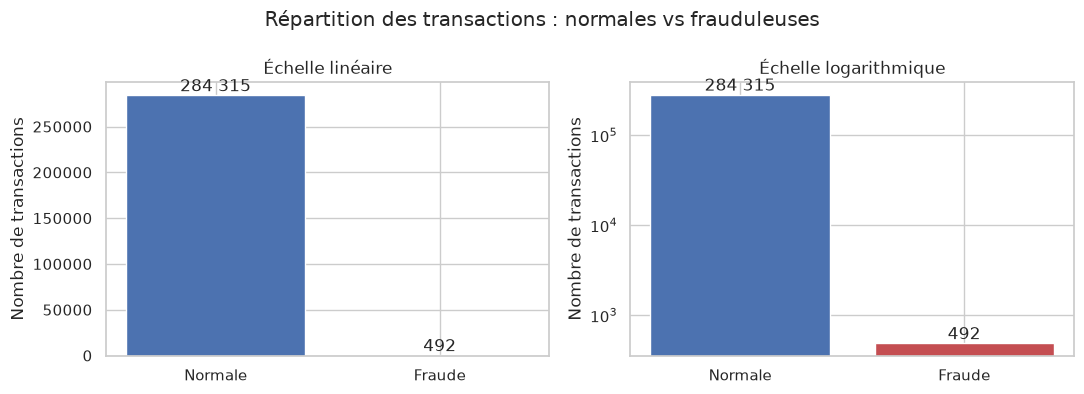

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
etiquettes = [NOMS[i] for i in comptes.index]
couleurs = [COULEURS[i] for i in comptes.index]
textes = [f"{v:,}".replace(",", " ") for v in comptes.values]

for ax, echelle in zip(axes, ["linear", "log"]):
    barres = ax.bar(etiquettes, comptes.values, color=couleurs)
    ax.bar_label(barres, labels=textes)
    ax.set_yscale(echelle)
    ax.set_title("Échelle linéaire" if echelle == "linear" else "Échelle logarithmique")
    ax.set_ylabel("Nombre de transactions")

plt.suptitle("Répartition des transactions : normales vs frauduleuses")
plt.tight_layout()
sauver("01_repartition_classes")
plt.show()

**Pourquoi deux graphiques ?** En échelle linéaire, la barre des fraudes est invisible. L'échelle logarithmique la rend visible, mais elle *déforme* l'écart réel : à garder en tête quand on lit ce type de graphique.

### Le piège de l'accuracy, version chiffrée

L’**accuracy** (ou **exactitude**) est une métrique qui mesure la proportion de prédictions correctes faites par un modèle de Machine Learning.

*Accuracy = nombre de prédictions correctes​ / nombre total de prédictions*

In [9]:
accuracy_modele_idiot = comptes[0] / len(df)
print(f"Un modèle qui répond toujours 'normale' aurait une accuracy de {accuracy_modele_idiot:.3%}")
print(f"... et détecterait {0} fraude sur {comptes[1]}.")

Un modèle qui répond toujours 'normale' aurait une accuracy de 99.827%
... et détecterait 0 fraude sur 492.


## 5. Analyse des montants (`Amount`)

Les montants sont en euros dans ce dataset. 

### 5.1 Statistiques par classe

In [10]:
resume_montants = df.groupby("Class")["Amount"].describe()
resume_montants.index = resume_montants.index.map(NOMS)
display(resume_montants)

print("Asymétrie (skewness) de Amount :", round(df["Amount"].skew(), 2))
print("   (0 = symétrique ; plus c'est grand et positif, plus il y a de très gros montants)")
print()
print("Montant maximum :", df["Amount"].max())
print("Transactions à 0 € :", int((df["Amount"] == 0).sum()),
      "dont fraudes :", int(((df["Amount"] == 0) & (df["Class"] == 1)).sum()))

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Normale,284315.0000,88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,25691.1600
Fraude,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,2125.8700


Asymétrie (skewness) de Amount : 16.98
   (0 = symétrique ; plus c'est grand et positif, plus il y a de très gros montants)

Montant maximum : 25691.16
Transactions à 0 € : 1825 dont fraudes : 27


### 5.2 Visualisation

### Comprendre la densité

**Le problème :** le jeu de données contient environ 284 000 transactions normales pour seulement 492 fraudes. Si on traçait deux histogrammes en nombre de transactions, les barres des fraudes seraient minuscules à côté de celles des transactions normales, et on ne pourrait rien comparer.

**La solution :** tracer des **proportions** au lieu de nombres. Chaque groupe est mis à l'échelle pour que l'aire totale de ses barres vaille 1 (soit 100 %). C'est comme comparer la répartition des âges d'une grande ville et d'un petit village : on utilise des pourcentages, pas des effectifs.

#### Comment la densité est calculée

Pour chaque barre de l'histogramme :

$$\text{densité de la barre} = \frac{\text{nombre de transactions dans la barre}}{\text{nombre total de transactions du groupe} \times \text{largeur de la barre}}$$

Deux choses à noter :

1. **On divise par le total du groupe.** C'est ce qui met fraudes et transactions normales sur la même échelle : les fraudes sont divisées par 492, les normales par environ 284 000.
2. **On divise aussi par la largeur de la barre.** C'est ce qui garantit que l'aire totale vaut 1.

**Exemple illustratif :** imaginons que 110 fraudes sur 492 tombent dans une barre de largeur 0,15 sur l'axe.
- Part des fraudes dans cette barre : 110 / 492 ≈ 22 %
- Densité : 110 / (492 × 0,15) ≈ **1,49**

**Vérification de l'aire :** aire d'une barre = hauteur × largeur = densité × largeur = nombre dans la barre / total du groupe, c'est-à-dire la **part** du groupe contenue dans la barre. En additionnant toutes les barres, on obtient 100 % du groupe, soit une aire de **1**.

#### Comment lire l'axe vertical

Ce n'est **pas** directement un pourcentage. La part des transactions contenues dans une barre est sa **hauteur multipliée par sa largeur**. Une densité peut donc dépasser 1 sans problème : si les barres sont étroites (par exemple 0,15), une barre de hauteur 1,5 contient seulement 1,5 × 0,15 ≈ 22 % du groupe.

> **À retenir :** avec la densité, on compare des *formes*, pas des volumes. Un pic rouge haut signifie « une grande partie des fraudes se concentre ici », même s'il y a très peu de fraudes en tout.

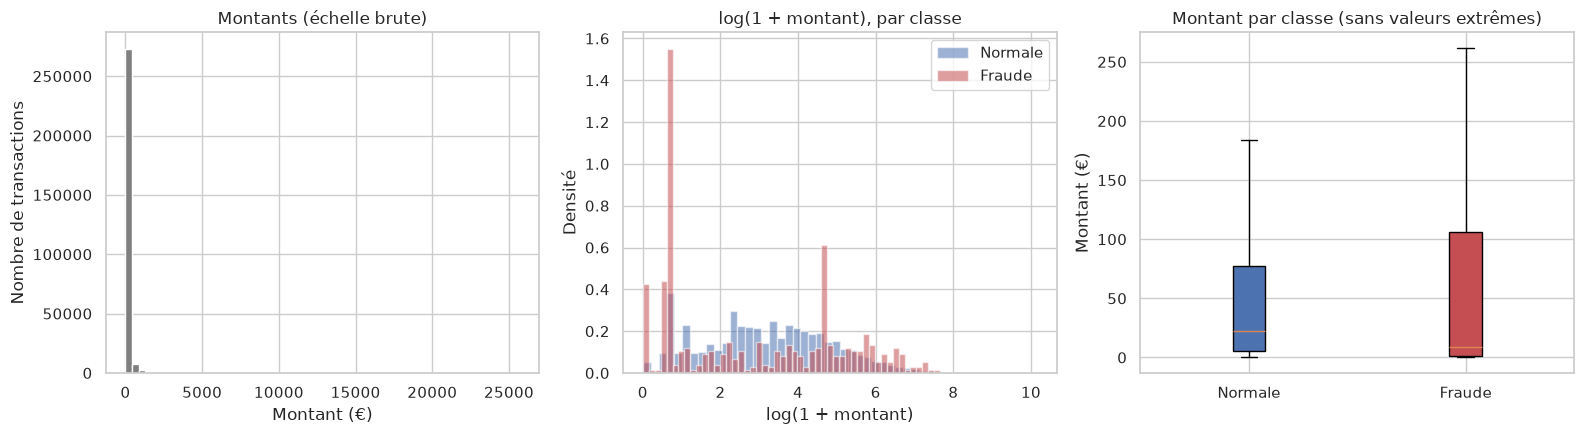

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Histogramme brut
axes[0].hist(df["Amount"], bins=60, color="#7f7f7f")
axes[0].set_title("Montants (échelle brute)")
axes[0].set_xlabel("Montant (€)")
axes[0].set_ylabel("Nombre de transactions")

# (b) Histogramme en log1p, par classe (densité pour comparer malgré le déséquilibre)
for c in (0, 1):
    valeurs = np.log1p(df.loc[df["Class"] == c, "Amount"])
    axes[1].hist(valeurs, bins=50, density=True, alpha=0.55, color=COULEURS[c], label=NOMS[c])
axes[1].set_title("log(1 + montant), par classe")
axes[1].set_xlabel("log(1 + montant)")
axes[1].set_ylabel("Densité")
axes[1].legend()

# (c) Boxplot par classe
bp = axes[2].boxplot(
    [df.loc[df["Class"] == 0, "Amount"], df.loc[df["Class"] == 1, "Amount"]],
    showfliers=False, patch_artist=True,
)
for boite, c in zip(bp["boxes"], (0, 1)):
    boite.set_facecolor(COULEURS[c])
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(["Normale", "Fraude"])
axes[2].set_title("Montant par classe (sans valeurs extrêmes)")
axes[2].set_ylabel("Montant (€)")

plt.tight_layout()
sauver("02_montants")
plt.show()

### 5.3 Taux de fraude par tranche de montant

Question : la fraude est-elle plus fréquente sur certains montants ?

,Nb transactions,Nb fraudes,Taux de fraude (%)
Amount,,,
0-1 €,30492,181,0.5936
1-10 €,69772,68,0.0975
10-50 €,90781,57,0.0628
50-100 €,37254,56,0.1503
100-500 €,47366,95,0.2006
500-1000 €,6202,26,0.4192
> 1000 €,2940,9,0.3061


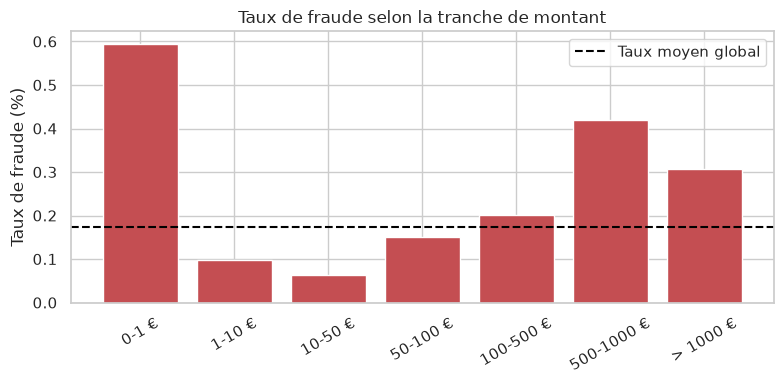

In [12]:
bornes = [-0.01, 1, 10, 50, 100, 500, 1000, np.inf]
noms_tranches = ["0-1 €", "1-10 €", "10-50 €", "50-100 €", "100-500 €", "500-1000 €", "> 1000 €"]
tranches = pd.cut(df["Amount"], bins=bornes, labels=noms_tranches)

par_tranche = df.groupby(tranches, observed=True)["Class"].agg(["count", "sum"])
par_tranche.columns = ["Nb transactions", "Nb fraudes"]
par_tranche["Taux de fraude (%)"] = par_tranche["Nb fraudes"] / par_tranche["Nb transactions"] * 100
display(par_tranche)

plt.figure(figsize=(8, 4))
plt.bar(par_tranche.index.astype(str), par_tranche["Taux de fraude (%)"], color=COULEURS[1])
plt.axhline(df["Class"].mean() * 100, color="black", linestyle="--", label="Taux moyen global")
plt.title("Taux de fraude selon la tranche de montant")
plt.ylabel("Taux de fraude (%)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
sauver("03_taux_fraude_par_montant")
plt.show()

## 6. Analyse temporelle (`Time`)

`Time` = secondes écoulées depuis la **première** transaction du jeu de données. On ne connaît pas l'heure réelle de départ, donc on raisonne en **heures écoulées** (de 0 à 48).


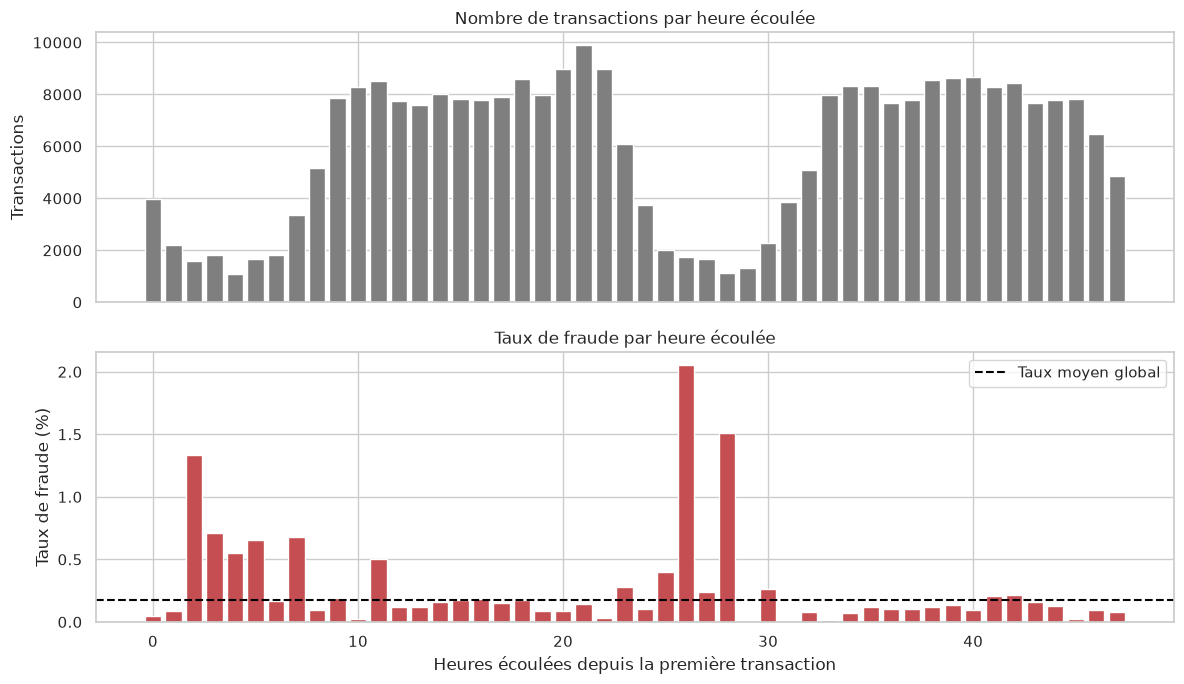

In [14]:
heures_ecoulees = (df["Time"] // 3600).astype(int)   # 0 à 47

volume = heures_ecoulees.value_counts().sort_index()
fraudes_par_heure = df.loc[df["Class"] == 1].groupby(heures_ecoulees[df["Class"] == 1]).size()
fraudes_par_heure = fraudes_par_heure.reindex(volume.index, fill_value=0)
taux_par_heure = fraudes_par_heure / volume * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(volume.index, volume.values, color="#7f7f7f")
axes[0].set_title("Nombre de transactions par heure écoulée")
axes[0].set_ylabel("Transactions")

axes[1].bar(taux_par_heure.index, taux_par_heure.values, color=COULEURS[1])
axes[1].axhline(df["Class"].mean() * 100, color="black", linestyle="--", label="Taux moyen global")
axes[1].set_title("Taux de fraude par heure écoulée")
axes[1].set_xlabel("Heures écoulées depuis la première transaction")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].legend()

plt.tight_layout()
sauver("04_analyse_temporelle")
plt.show()

**Comment lire :**
- Le graphique du haut montre le rythme d'activité. Sur deux jours complets, on s'attend à voir deux « creux » (la nuit), espacés d'environ 24 heures.
- Celui du bas montre si la fraude se concentre à certaines heures. Comme les fraudes sont très peu nombreuses (492 sur 48 h), le taux fluctue beaucoup d'une heure à l'autre.
- L'heure de départ réelle est inconnue. Si les creux correspondent à la nuit, alors la première transaction a eu lieu en début de journée ou de nuit : c'est une hypothèse, pas une certitude.


## 7. Les variables anonymisées `V1` à `V28`

Ces variables sont le résultat d'une PCA : leur signification métier est inconnue, mais on peut mesurer lesquelles **différencient le mieux** les fraudes des transactions normales.

### 7.1 Ordre de grandeur

In [15]:
display(df[V_COLS].agg(["mean", "std", "min", "max"]).T)

,mean,std,min,max
V1,0.0000,1.9587,-56.4075,2.4549
V2,0.0000,1.6513,-72.7157,22.0577
V3,-0.0000,1.5163,-48.3256,9.3826
V4,0.0000,1.4159,-5.6832,16.8753
V5,0.0000,1.3802,-113.7433,34.8017
V6,0.0000,1.3323,-26.1605,73.3016
V7,-0.0000,1.2371,-43.5572,120.5895
V8,0.0000,1.1944,-73.2167,20.0072
V9,-0.0000,1.0986,-13.4341,15.5950
V10,0.0000,1.0888,-24.5883,23.7451


Les moyennes sont proches de 0 : c'est normal, la PCA centre les données. Les minimums et maximums très éloignés de la moyenne signalent des valeurs extrêmes.

### 7.2 Quelles variables distinguent le mieux les fraudes ?

On calcule l'**écart standardisé** entre la moyenne des fraudes et celle des transactions normales :

> écart standardisé = (moyenne fraude - moyenne normale) / écart-type global

Plus la valeur absolue est grande, plus la variable sépare les deux groupes. Le signe indique le sens (positif : plus élevée chez les fraudes).

Les 10 variables les plus discriminantes :


,Écart standardisé
V17,-7.8619
V14,-7.2854
V12,-6.2752
V10,-5.2227
V16,-4.7328
V3,-4.6466
V7,-4.5093
V11,3.7295
V4,3.2135
V18,-2.6846


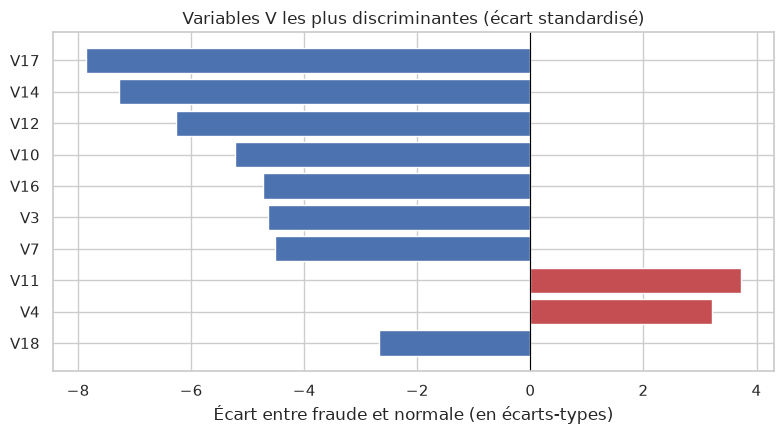

In [16]:
moyennes = df.groupby("Class")[V_COLS].mean()
ecart_std = (moyennes.loc[1] - moyennes.loc[0]) / df[V_COLS].std()
ecart_std = ecart_std.sort_values(key=np.abs, ascending=False)

print("Les 10 variables les plus discriminantes :")
display(ecart_std.head(10).to_frame("Écart standardisé"))

top10 = ecart_std.head(10).iloc[::-1]
plt.figure(figsize=(8, 4.5))
plt.barh(top10.index, top10.values, color=[COULEURS[1] if v > 0 else COULEURS[0] for v in top10.values])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Variables V les plus discriminantes (écart standardisé)")
plt.xlabel("Écart entre fraude et normale (en écarts-types)")
plt.tight_layout()
sauver("05a_variables_discriminantes")
plt.show()

### 7.3 Distributions des 6 variables les plus discriminantes

Chaque graphique superpose la distribution des transactions normales (bleu) et des fraudes (rouge). On utilise la **densité** (aire égale à 1) pour pouvoir comparer malgré le déséquilibre des effectifs. Les valeurs extrêmes (0,5 % de chaque côté) sont ramenées aux bornes pour garder des graphiques lisibles.

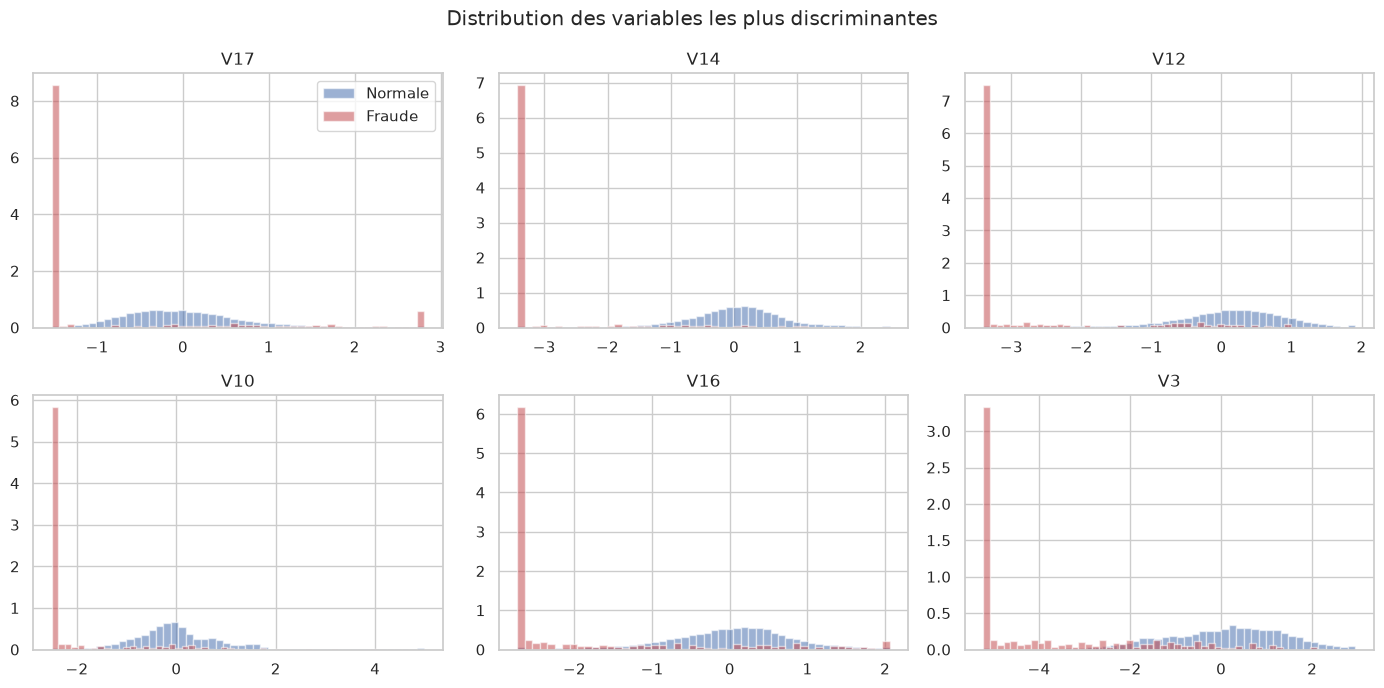

In [17]:
top6 = ecart_std.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), top6):
    bas, haut = df[col].quantile([0.005, 0.995])
    for c in (0, 1):
        ax.hist(df.loc[df["Class"] == c, col].clip(bas, haut), bins=50, density=True,
                alpha=0.55, color=COULEURS[c], label=NOMS[c])
    ax.set_title(col)
axes[0, 0].legend()

plt.suptitle("Distribution des variables les plus discriminantes")
plt.tight_layout()
sauver("05b_distributions_top6")
plt.show()

### 7.4 Les « valeurs aberrantes » sont-elles des erreurs ?

Méthode classique (IQR) : une valeur est dite extrême si elle sort de l'intervalle `[Q1 - 1,5 x IQR ; Q3 + 1,5 x IQR]`. Regardons quelle part des transactions normales et des fraudes est « hors bornes ».

In [18]:
lignes = []
for col in top6:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    hors_bornes = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    lignes.append({
        "Variable": col,
        "% normales hors bornes": hors_bornes[df["Class"] == 0].mean() * 100,
        "% fraudes hors bornes": hors_bornes[df["Class"] == 1].mean() * 100,
    })

display(pd.DataFrame(lignes).set_index("Variable"))

,% normales hors bornes,% fraudes hors bornes
Variable,,
V17,2.4701,80.6911
V14,4.8253,87.3984
V12,5.2544,83.1301
V10,3.1996,81.0976
V16,2.7550,71.3415
V3,1.0731,63.4146


## 8. Corrélations

La **corrélation** mesure à quel point deux variables évoluent ensemble, entre -1 et +1 :
- proche de +1 : elles augmentent ensemble
- proche de -1 : quand l'une monte, l'autre descend
- proche de 0 : pas de lien linéaire

> ⚠️ Corrélation n'est pas causalité. Et elle ne détecte que les liens **linéaires**.

### 8.1 Corrélation de chaque variable avec la cible

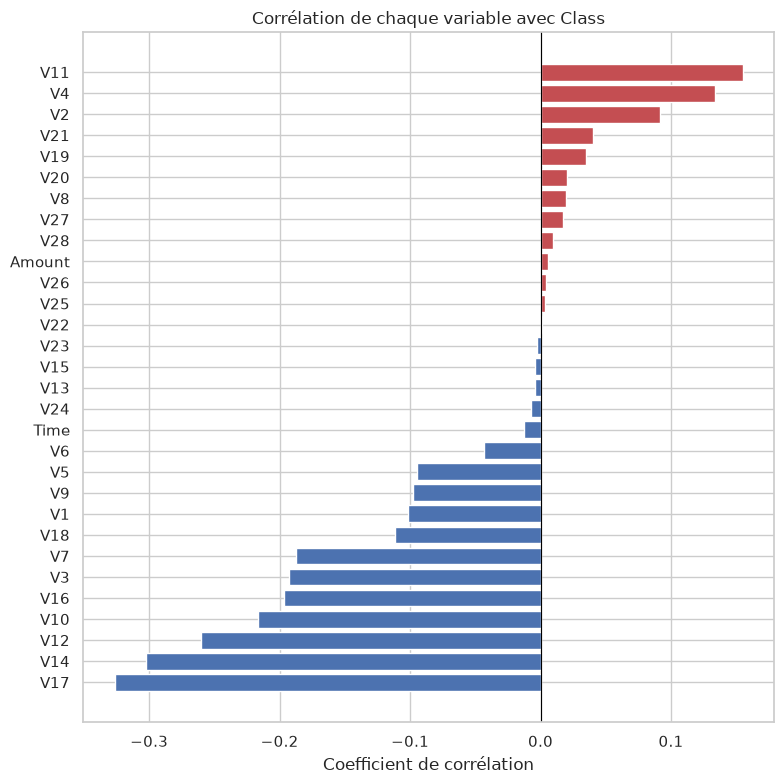

Les 5 corrélations les plus fortes (en valeur absolue) :


,Corrélation
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965


In [19]:
corr = df.corr()
corr_cible = corr["Class"].drop("Class").sort_values()

plt.figure(figsize=(8, 8))
plt.barh(corr_cible.index, corr_cible.values,
         color=[COULEURS[1] if v > 0 else COULEURS[0] for v in corr_cible.values])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Corrélation de chaque variable avec Class")
plt.xlabel("Coefficient de corrélation")
plt.tight_layout()
sauver("06_correlation_avec_cible")
plt.show()

print("Les 5 corrélations les plus fortes (en valeur absolue) :")
display(corr_cible.reindex(corr_cible.abs().sort_values(ascending=False).index).head(5).to_frame("Corrélation"))

### 8.2 Matrice de corrélation complète

Chaque case montre la corrélation entre deux variables. Rouge = corrélation positive, bleu = négative, blanc = aucune.

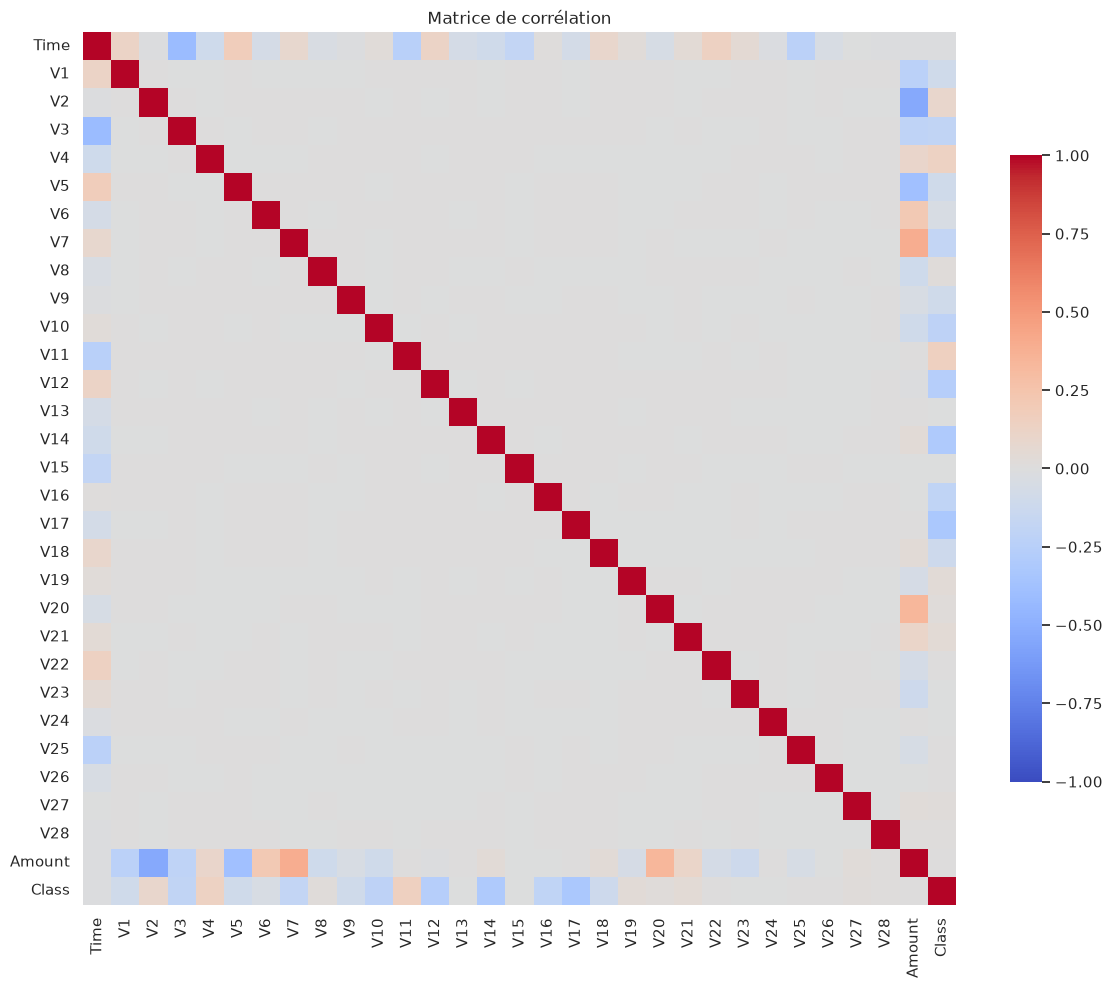

In [20]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7})
plt.title("Matrice de corrélation")
plt.tight_layout()
sauver("07_matrice_correlation")
plt.show()

### 8.3 Corrélation entre les variables `V` elles-mêmes

Comme `V1`-`V28` viennent d'une PCA, elles sont construites pour être **indépendantes les unes des autres**. Vérifions :

In [21]:
corr_vv = corr.loc[V_COLS, V_COLS].abs().values.copy()
np.fill_diagonal(corr_vv, 0)
print("Corrélation maximale entre deux variables V différentes :", f"{corr_vv.max():.2e}")

print()
print("Variables V les plus corrélées avec Amount :")
display(corr.loc[V_COLS, "Amount"].sort_values(key=np.abs, ascending=False).head(4).to_frame("Corrélation avec Amount"))

print("Variables V les plus corrélées avec Time :")
display(corr.loc[V_COLS, "Time"].sort_values(key=np.abs, ascending=False).head(4).to_frame("Corrélation avec Time"))

Corrélation maximale entre deux variables V différentes : 2.32e-14

Variables V les plus corrélées avec Amount :


,Corrélation avec Amount
V2,-0.5314
V7,0.3973
V5,-0.3864
V20,0.3394


Variables V les plus corrélées avec Time :


,Corrélation avec Time
V3,-0.4196
V11,-0.2477
V25,-0.2331
V15,-0.1835


Une corrélation quasi nulle entre les `V` signifie qu'elles n'apportent pas d'information redondante entre elles (pas de multicolinéarité). En revanche, `Amount` et `Time` ne font pas partie de la PCA et peuvent être corrélés à certaines `V`.

## 9. Les fraudes sont-elles visuellement séparables ?

On trace les deux variables les plus corrélées à la cible l'une contre l'autre.

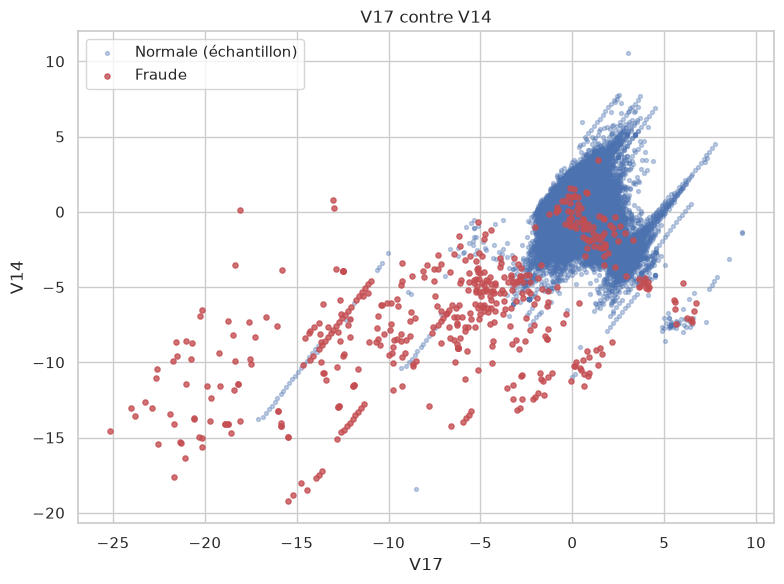

In [26]:
top2 = corr_cible.abs().sort_values(ascending=False).head(2).index.tolist()

normales = df[df["Class"] == 0]
fraudes = df[df["Class"] == 1]

plt.figure(figsize=(8, 6))
plt.scatter(normales[top2[0]], normales[top2[1]], s=8, alpha=0.35, color=COULEURS[0], label="Normale (échantillon)")
plt.scatter(fraudes[top2[0]], fraudes[top2[1]], s=14, alpha=0.8, color=COULEURS[1], label="Fraude")
plt.xlabel(top2[0])
plt.ylabel(top2[1])
plt.title(f"{top2[0]} contre {top2[1]}")
plt.legend()
plt.tight_layout()
sauver("08_separabilite")
plt.show()

## 11. Sauvegarde du résumé de l'exploration

On conserve les chiffres clés dans un fichier JSON : c'est utile pour ton rapport final et pour garder une trace de ce qui a été observé.

In [27]:
montants = df.groupby("Class")["Amount"]

resume_eda = {
    "date_analyse": datetime.now().isoformat(timespec="seconds"),
    "nb_lignes": int(len(df)),
    "nb_fraudes": int(df["Class"].sum()),
    "taux_fraude_pct": round(float(df["Class"].mean() * 100), 4),
    "valeurs_manquantes": int(manquantes),
    "nb_doublons": int(n_doublons),
    "montant": {
        "moyenne_normale": round(float(montants.mean()[0]), 2),
        "moyenne_fraude": round(float(montants.mean()[1]), 2),
        "mediane_normale": round(float(montants.median()[0]), 2),
        "mediane_fraude": round(float(montants.median()[1]), 2),
        "maximum": round(float(df["Amount"].max()), 2),
    },
    "variables_les_plus_correlees_avec_class": {
        nom: round(float(corr_cible[nom]), 4)
        for nom in corr_cible.abs().sort_values(ascending=False).head(6).index
    },
    "figures": sorted(p.name for p in FIG_DIR.glob("*.png")),
}

chemin_resume = PROCESSED_DIR / "eda_resume.json"
with open(chemin_resume, "w", encoding="utf-8") as f:
    json.dump(resume_eda, f, ensure_ascii=False, indent=2)

print("Résumé enregistré :", chemin_resume)
print("Figures sauvegardées dans :", FIG_DIR)

Résumé enregistré : /home/virlence-manga-bell/Documents/DataScience/fraude-bancaire-detection/data/processed/eda_resume.json
Figures sauvegardées dans : /home/virlence-manga-bell/Documents/DataScience/fraude-bancaire-detection/reports/figures
